# Import libraries

In [1]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner

# Define constants

In [8]:
c = 299792.458 #is this in the correct units?
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)
megaparsec = 3.0856775814913673 * 10**10

# Some key functions

In [9]:
#order of variables: z, omega_k, omega_M, omega_DE, H0, rc

def Friedmann_eq2(z, theta):
    omega_k, omega_M, H0, w = theta
    omega_DE = 1 - omega_k - omega_M
    H2 = (omega_M*(1+z)**3 + omega_DE*(1+z)**(3*(1+w)) - omega_k*(1+z)**2)
    return H2

def integrand(z, theta):
    return 1/np.sqrt(Friedmann_eq2(z, theta))

def co_moving_dist(z_up, theta):
    z_up = np.concatenate(([0], z_up))
    r_cm = scp.integrate.odeint(lambda y, t: integrand(t, theta), 0, z_up)
    r_c = np.delete(r_cm, 0)
    return np.ndarray.flatten(r_c)

def Sk(omega_k, H0, rc): #units issue?
    if omega_k == 0:
        return c*rc/H0
    if omega_k < 0:
        return (c/(H0*np.sqrt(-omega_k)))*np.sin(np.sqrt(-omega_k)*rc)
    return (c/(H0*np.sqrt(omega_k)))*np.sinh(np.sqrt(omega_k)*rc)

def dist_modulus(z, theta):
    omega_k, omega_M, H0, w = theta
    rc = co_moving_dist(z, theta)
    s_k = Sk(omega_k, H0, rc)
    dl = (1+z)*s_k
    if not np.all(dl>0):
        print(f"luminosity distance isn't positive, {dl}, {s_k}, {rc}, {theta}")
    dist_mod = 5*np.log10(dl) + 25
    return dist_mod

In [10]:
#different equations of state:

"""w = w0 #wCDM
w = w0 + wa*(1+z)"""


'w = w0 #wCDM\nw = w0 + wa*(1+z)'

# Load the data

In [11]:
sn_z, sn_z_err, sn_mu, sn_mu_err = np.loadtxt("pantheon-plus+SH0ES-SN.txt", usecols=(2,3,4,5), unpack = True)
covmat_file = np.loadtxt("Pantheon+SH0ES_STAT+SYS.cov")
covmat_file_dim = int(covmat_file[0])
covmat_file = np.delete(covmat_file, 0)
covmat = np.zeros((covmat_file_dim, covmat_file_dim))
covmat.shape
for i in range(covmat_file_dim):
    covmat[i] = covmat_file[i*covmat_file_dim:(i+1)*covmat_file_dim]
covmat_inv = np.linalg.inv(covmat)


## Priors

Parameters of model are: {k, H0, omega_M, omega_DE}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [12]:
H0_prior = 69.02
H0_stdev_prior = 2.08*5
omega_DE_prior = 0.6889
omega_DE_stdev_prior = 0.0056
omega_M_prior = 0.31
omega_M_stdev_prior = 0.04

def log_prior(theta, z):
    omega_k, omega_M, H0, w0 = theta
    H2 = Friedmann_eq2(z, theta)
    if not (-0.5<omega_k<0.5 and np.all(H2>0) and -1<w0<1 and H0>0):
        return -np.inf
    return -0.5*(omega_M-omega_M_prior)**2/omega_M_stdev_prior**2 -0.5*(H0-H0_prior)**2/H0_stdev_prior**2

nparams = 4
nwalkers = 50
pos = np.zeros((nwalkers, nparams))
for i in range(len(pos)):
    pos[i][0] = np.random.uniform(-0.005, 0.005)
    pos[i][1] = np.random.uniform(0.2, 0.4)
    pos[i][2] = np.random.uniform(20, 100)
    pos[i][3] = np.random.uniform(-1,1)
    

# Likelihood function

In [13]:
def log_likelihood(theta, z, mu, covmatrix_inv):
    model = dist_modulus(z, theta)
    resids = mu - model
    chi2 = np.matmul(np.matmul(resids, covmatrix_inv), resids)
    return -0.5*chi2
    


def log_probability(theta, z, mu, covmatrix_inv):
    lp = log_prior(theta, z)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, covmatrix_inv)


# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [14]:
nsteps = 5000 #number of steps walkers take
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mu, covmat_inv)
)
sampler.run_mcmc(pos, nsteps, progress = True)

100%|██████████| 5000/5000 [06:31<00:00, 12.79it/s]


State([[-1.68976661e-01  3.04678906e-01  6.30414151e+01 -9.11727768e-01]
 [ 2.16019590e-02  3.33849003e-01  7.45150984e+01 -9.28793972e-01]
 [ 1.74139574e-01  3.05488018e-01  8.97393212e+01 -8.29296572e-01]
 [-1.64874722e-01  2.45594927e-01  6.31366581e+01 -7.96131175e-01]
 [-9.52680016e-02  3.17726245e-01  6.68117018e+01 -9.26745992e-01]
 [ 7.37973746e-02  3.62778782e-01  7.87674899e+01 -9.78999325e-01]
 [ 6.50948752e-02  3.25923271e-01  7.79298056e+01 -8.72944357e-01]
 [-1.89742383e-02  3.37198426e-01  7.16565198e+01 -9.51998907e-01]
 [-2.62048542e-01  2.99072076e-01  5.91171190e+01 -9.11965214e-01]
 [-9.29226085e-02  3.63518890e-01  6.65615549e+01 -9.31680552e-01]
 [-8.64069570e-03  3.04937466e-01  7.20045997e+01 -8.51395453e-01]
 [-1.16293960e-01  3.11428594e-01  6.57590196e+01 -9.48082454e-01]
 [ 7.63879796e-02  3.33702783e-01  7.86788137e+01 -8.87556804e-01]
 [-1.06187189e-01  3.12284760e-01  6.63296622e+01 -9.05738525e-01]
 [-5.89563317e-02  2.72366450e-01  6.81995229e+01 -7.363

In [20]:
sampler.run_mcmc(None, 30000, progress = True)
ndiscard = 200 #how many steps at the beginning of the chain to discard
flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(nparams, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["$Ω_{k0}$", "$Ω_{M0}$", "$H_{0}$", "$w_{0}$"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
#plt.savefig("walkers_wCDM.png")
print(f"autocorrelation time is {sampler.get_autocorr_time()}")

 19%|█▊        | 5610/30000 [31:35<1:33:19,  4.36it/s] 

emcee: Exception while calling your likelihood function:
  params: [ 0.17739448  0.32386918 89.74103996 -0.86341356]
  args: (array([1.22000e-03, 1.22000e-03, 2.56000e-03, ..., 1.80119e+00,
       1.91165e+00, 2.26137e+00]), array([28.9987, 29.0559, 30.7233, ..., 45.4865, 45.4233, 46.1828]), array([[ 3.35405114e+01, -5.68645204e+00, -1.07870284e-01, ...,
         1.44562418e-02,  1.73619146e-02,  6.56463541e-02],
       [-5.68645201e+00,  3.26679150e+01,  6.27809019e-01, ...,
         5.90524514e-02,  5.86751704e-02,  9.18237282e-02],
       [-1.07870328e-01,  6.27808965e-01,  5.66302667e+01, ...,
         4.04987268e-02,  6.08045796e-02,  1.44339360e-01],
       ...,
       [ 1.44562147e-02,  5.90524254e-02,  4.04987139e-02, ...,
         2.64804296e+01, -2.56390503e-01, -5.18344051e-01],
       [ 1.73618976e-02,  5.86751545e-02,  6.08045714e-02, ...,
        -2.56390503e-01,  1.63294720e+01, -4.65796138e-01],
       [ 6.56463083e-02,  9.18236857e-02,  1.44339335e-01, ...,
        -5.

Traceback (most recent call last):
  File "C:\Users\milan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\emcee\ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Temp\ipykernel_14848\3231594283.py", line 10, in log_probability
    lp = log_prior(theta, z)
         ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Temp\ipykernel_14848\2585505708.py", line 11, in log_prior
    if not (-0.5<omega_k<0.5 and np.all(H2>0) and -1<w0<1 and H0>0):
                                 ^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py", line 2416, in _all_dispatcher
    def _all_dispatcher(a, axis=None, out=None, keepdims=None, *,
    
KeyboardInterrupt
 19%|█▊        

KeyboardInterrupt: 

# Covariance plots

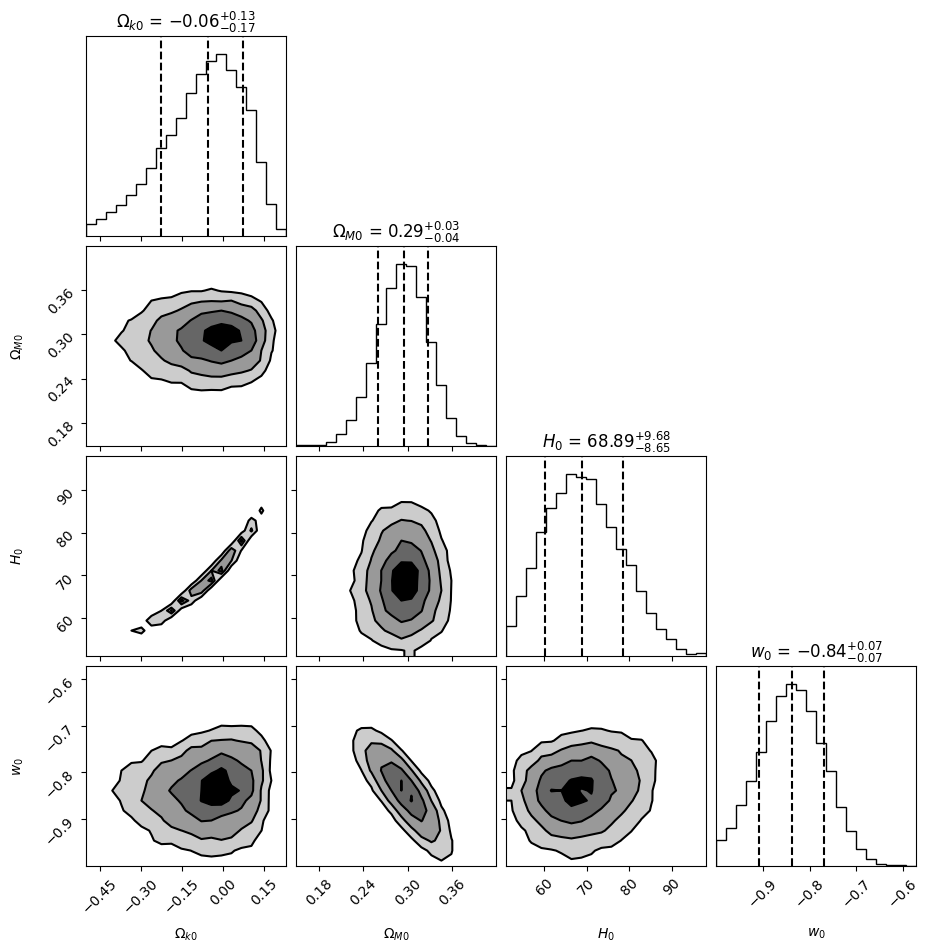

In [19]:
#fig, axs = plt.subplots(4,4)
fig = corner.corner(
    flat_samples, labels = labels, quantiles=[0.16,0.5,0.84], show_titles=True, title_kwargs={"fontsize": 12}, plot_datapoints=False, fill_contours = True
)
#axs[0,0].set_facecolor("lightblue")
plt.show()
#plt.suptitle('CORNER PLOT')
#plt.savefig('test_corner.png')
#plt.show()
plt.close()
#plt.savefig("corner_wCDM.png")

In [62]:
with open("flat_samples_wCDM.txt", "a") as f:
    samples = sampler.get_chain(flat = True)
    for walkercoords in samples:
        f.write(str(walkercoords))
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]} + {q[1]} - {q[0]}")

$Ω_{k0}$: 0.06393404292857705 + 0.06005389751372235 - 0.06731259315111782
$Ω_{Λ0}$: 0.6855828675903028 + 0.016909754060264737 - 0.017052808209432224
$H_{0}$: 77.68083045677527 + 5.815970202512574 - 5.2841049704210405
w: -0.7498100281871105 + 0.11033251508313224 - 0.13127061953125818


In [14]:
theta_model = np.zeros(nparams)
for i in range(nparams):
    theta_model[i] = np.percentile(flat_samples[:, i], [50])[0]

chi-squared: 1748.555439451863


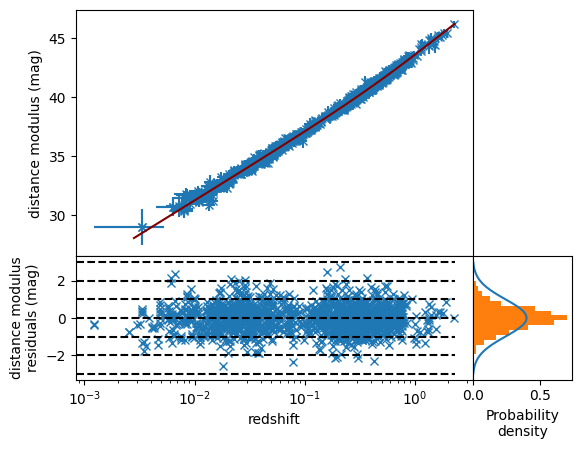

BIC: 1778.3113258214466


In [15]:
model_z = np.linspace(0.001, 2.3, 1000)
model_mu = dist_modulus(model_z, theta_model)
resids = sn_mu - dist_modulus(sn_z, theta_model)
chisqval = np.matmul(np.matmul(resids, covmat_inv), resids)


fig, axs = plt.subplots(2, 2, width_ratios=[4,1], height_ratios=[2,1])
axs[0,0].plot(model_z, model_mu, color = "maroon", zorder = 2)

axs[0,0].errorbar(sn_z, sn_mu, xerr=sn_z_err, yerr = sn_mu_err, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(2,0,2.3, linestyle = "--", color = "black")
norm_resids = (dist_modulus(sn_z, theta_model) - sn_mu)/sn_mu_err
print(f"chi-squared: {chisqval}")
axs[1,0].errorbar(sn_z, norm_resids, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-2,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(0,0,2.3, linestyle = "--", color = "black", zorder = 2)
axs[1,0].set_xlabel("redshift")
axs[0,0].set_ylabel("distance modulus (mag)")
axs[1,0].set_ylabel("distance modulus\nresiduals (mag)")
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)
#axs[0,0].invert_yaxis()
axs[0,0].set_xscale("log")
axs[1,0].set_xscale("log")
axs[0,1].remove()
axs[1,1].get_yaxis().set_visible(False)
xs = np.linspace(-3,3)
axs[1,1].plot(scp.stats.norm.pdf(xs, 0, 1), xs)
axs[1,1].set_xlabel("Probability\ndensity")
axs[1,1].hist(norm_resids, density = True, orientation = u'horizontal', bins = np.linspace(-3, 3, 24))
plt.savefig("plot_wCDM", bbox_inches = "tight")
plt.show()
BIC = nparams*np.log(covmat_file_dim) + chisqval
print(f"BIC: {BIC}")

AttributeError: 'Figure' object has no attribute 'plot'